# ⚖️ Notebook 01b — Undersampling (Balancing Neutral Class)
### Quality-Aware FER Project

**Dataset:** Folder `dataset/` dengan struktur `train/ validation/ test/`
**Target:** Menyeimbangkan kelas `neutral` (10,379 sampel) dengan kelas lain (masing-masing 8,000 sampel) di dalam split `train/`.

Notebook ini melakukan undersampling acak pada kelas `neutral` dengan memindahkan 2,379 gambar ke folder backup (`dataset/train_neutral_backup/`), sehingga semua kelas di split `train/` memiliki tepat 8,000 gambar.

In [1]:
import sys, os, random, shutil
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

# Temukan ROOT project secara robust
current_path = Path(".").resolve()
if (current_path / "src").exists() and (current_path / "configs").exists():
    ROOT = current_path
elif (current_path.parent / "src").exists() and (current_path.parent / "configs").exists():
    ROOT = current_path.parent
else:
    ROOT = Path("..").resolve()
sys.path.insert(0, str(ROOT))

plt.style.use("dark_background")
sns.set_palette("husl")
SAVE_DIR = ROOT / "results" / "plots" / "eda"
SAVE_DIR.mkdir(parents=True, exist_ok=True)

DATASET_ROOT = ROOT / "dataset"
TRAIN_DIR = DATASET_ROOT / "train"
BACKUP_DIR = DATASET_ROOT / "train_neutral_backup"

EMOTION_CLASSES = ["angry", "contempt", "disgust", "fear", "happy", "neutral", "sad", "suprise"]
COLORS = ["#ef4444","#a16207","#a855f7","#f97316","#22c55e","#94a3b8","#3b82f6","#eab308"]

print(f"✅ Root project  : {ROOT}")
print(f"📁 Dataset path  : {DATASET_ROOT}")
print(f"📁 Backup path   : {BACKUP_DIR}")

✅ Root project  : D:\BIG-Data\tuber
📁 Dataset path  : D:\BIG-Data\tuber\dataset
📁 Backup path   : D:\BIG-Data\tuber\dataset\train_neutral_backup


## 1. Analisis Sebelum Undersampling

In [2]:
# Hitung sampel awal
records_before = []
for emo in EMOTION_CLASSES:
    cls_dir = TRAIN_DIR / emo
    if not cls_dir.exists():
        continue
    imgs = list(cls_dir.glob("*.png")) + list(cls_dir.glob("*.jpg")) + list(cls_dir.glob("*.jpeg"))
    for img_path in imgs:
        records_before.append({
            "path": str(img_path),
            "emotion": emo
        })

df_before = pd.DataFrame(records_before)
counts_before = df_before["emotion"].value_counts().reindex(EMOTION_CLASSES, fill_value=0)

print("📊 Train class distribution (Sebelum Undersampling):")
for emo, cnt in counts_before.items():
    print(f"  {emo:<12}: {cnt:>6,}")

📊 Train class distribution (Sebelum Undersampling):
  angry       :  8,000
  contempt    :  8,000
  disgust     :  8,000
  fear        :  8,000
  happy       :  8,000
  neutral     :  8,000
  sad         :  8,000
  suprise     :  8,000


## 2. Proses Undersampling (Memindahkan Sampel Berlebih)

In [3]:
# Target jumlah per kelas
TARGET_COUNT = 8000
neutral_dir = TRAIN_DIR / "neutral"

if neutral_dir.exists():
    neutral_imgs = list(neutral_dir.glob("*.png")) + list(neutral_dir.glob("*.jpg")) + list(neutral_dir.glob("*.jpeg"))
    current_count = len(neutral_imgs)
    
    if current_count > TARGET_COUNT:
        to_remove_count = current_count - TARGET_COUNT
        print(f"\n⚡ Kelas neutral memiliki {current_count:,} gambar. Target: {TARGET_COUNT:,}.")
        print(f"   Memindahkan {to_remove_count:,} gambar ke folder backup...")
        
        # Buat backup dir jika belum ada
        BACKUP_DIR.mkdir(parents=True, exist_ok=True)
        
        # Shuffle gambar dengan seed tetap agar konsisten
        random.seed(42)
        random.shuffle(neutral_imgs)
        
        # Pisahkan gambar yang akan dipindah
        imgs_to_move = neutral_imgs[:to_remove_count]
        
        moved_count = 0
        for img_path in imgs_to_move:
            dest_path = BACKUP_DIR / img_path.name
            try:
                shutil.move(str(img_path), str(dest_path))
                moved_count += 1
            except Exception as e:
                print(f"❌ Gagal memindahkan {img_path.name}: {e}")
                
        print(f"✅ Berhasil memindahkan {moved_count:,} gambar.")
    else:
        print(f"\n✅ Jumlah gambar neutral sudah seimbang atau di bawah target ({current_count:,} gambar).")
else:
    print("\n⚠️ Folder kelas neutral tidak ditemukan.")


✅ Jumlah gambar neutral sudah seimbang atau di bawah target (8,000 gambar).


## 3. Analisis Setelah Undersampling

In [4]:
# Hitung sampel setelah undersampling
records_after = []
for emo in EMOTION_CLASSES:
    cls_dir = TRAIN_DIR / emo
    if not cls_dir.exists():
        continue
    imgs = list(cls_dir.glob("*.png")) + list(cls_dir.glob("*.jpg")) + list(cls_dir.glob("*.jpeg"))
    for img_path in imgs:
        records_after.append({
            "path": str(img_path),
            "emotion": emo
        })

df_after = pd.DataFrame(records_after)
counts_after = df_after["emotion"].value_counts().reindex(EMOTION_CLASSES, fill_value=0)

print("📊 Train class distribution (Setelah Undersampling):")
for emo, cnt in counts_after.items():
    print(f"  {emo:<12}: {cnt:>6,}")

📊 Train class distribution (Setelah Undersampling):
  angry       :  8,000
  contempt    :  8,000
  disgust     :  8,000
  fear        :  8,000
  happy       :  8,000
  neutral     :  8,000
  sad         :  8,000
  suprise     :  8,000


## 4. Visualisasi Distribusi Baru

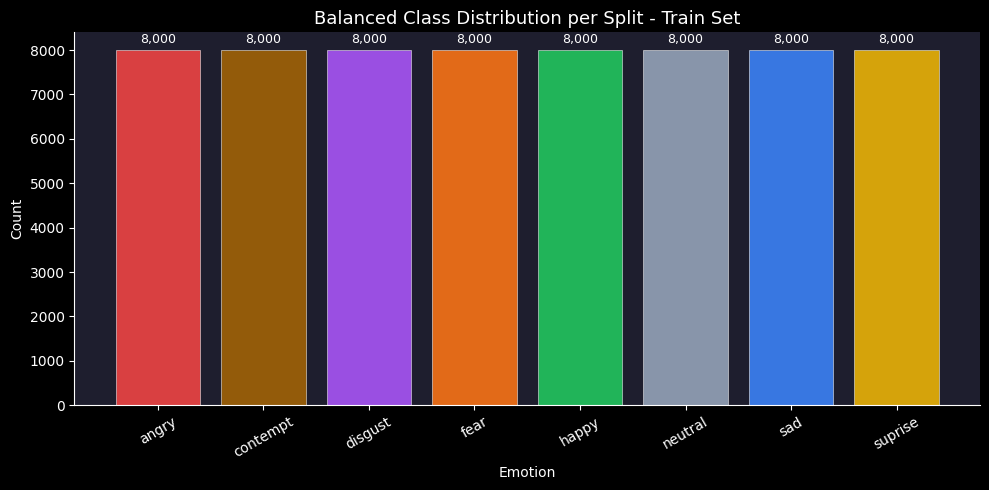

✅ Saved plot to: D:\BIG-Data\tuber\results\plots\eda\01b_balanced_class_distribution.png


In [5]:
fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.bar(counts_after.index, counts_after.values,
              color=COLORS, edgecolor="white", linewidth=0.4, alpha=0.9)

for bar in bars:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 100,
            f"{int(bar.get_height()):,}", ha="center", va="bottom", fontsize=9, color="white")

ax.set_title("Balanced Class Distribution per Split - Train Set", color="white", fontsize=13)
ax.set_xlabel("Emotion", color="white")
ax.set_ylabel("Count", color="white")
ax.tick_params(axis="x", rotation=30, colors="white")
ax.tick_params(axis="y", colors="white")
ax.set_facecolor("#1e1e2e")
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.tight_layout()
plot_save_path = SAVE_DIR / "01b_balanced_class_distribution.png"
plt.savefig(plot_save_path, dpi=150, bbox_inches="tight", facecolor="#0f1117")
plt.show()
print(f"✅ Saved plot to: {plot_save_path}")